# Linear elasticity: material robustness

2D cantilevered rectangular beam under gravity. Fixed on the left face; traction-free on the right, top, and bottom.

Hellinger–Reissner mixed formulation with the Johnson–Mercier element (symmetric $P_1$ stress in $H(\operatorname{div})$, $P_0$ displacement). The zero-displacement BC on the clamped face is natural (prescribed displacement enters the RHS and vanishes since $g=0$); zero traction on the free faces is the essential BC on the stress space.

In [2]:
try:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-development-real.sh" -O "/tmp/firedrake-install.sh"
    !bash "/tmp/firedrake-install.sh"
    from firedrake import *  # noqa: F401
except:
    from firedrake import *  # noqa: F401

--2026-05-27 20:49:06--  https://fem-on-colab.github.io/releases/firedrake-install-development-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4775 (4.7K) [application/x-sh]
Saving to: ‘/tmp/firedrake-install.sh’

/tmp/firedrake-inst 100%[===================>]   4.66K  --.-KB/s    in 0s      

2026-05-27 20:49:06 (45.2 MB/s) - ‘/tmp/firedrake-install.sh’ saved [4775/4775]

+ INSTALL_PREFIX=/usr/local
++ awk -F/ '{print NF-1}'
++ echo /usr/local
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FIREDRAKE_INSTALLED=/usr/local/share/fem-on-colab/firedrake.installed
+ [[ ! -f /usr/local/share/fem-on-colab/firedrake.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/

In [103]:
# Rectangular beam: length x height
length, height = 5.0, 1.0
mesh = RectangleMesh(round(10*length), round(10*height), length, height)
n = FacetNormal(mesh)
x, y = SpatialCoordinate(mesh)
d = 2  # spatial dimension

# Material parameters
E   = Constant(1e6)   # Young's modulus
nu  = Constant(0.3)   # Poisson's ratio
rho = Constant(1e3)   # density

mu    = E / (2*(1 + nu))
lmbda = E*nu / ((1 + nu)*(1 - 2*nu))

In [104]:
JM = FunctionSpace(mesh, "JM", 1)
DG = VectorFunctionSpace(mesh, "DG", 0, variant="alfeld")
W = JM * DG

sigma, u_0 = TrialFunctions(W)
tau,   v   = TestFunctions(W)

phi = x**2 * (x - length)**2
phi_prime = 2*x * (x - length)**2 + x**2 * 2*(x - length)
u_BC = as_vector([
    - (y - height/2) * phi_prime,
    phi
])

def A(s):
    """Compliance tensor: inverse of the Lame elasticity tensor."""
    return (1/(2*mu))*s - (lmbda/(2*mu*(2*mu + d*lmbda)))*tr(s)*Identity(d)

a = (inner(A(sigma), tau) + inner(u_0, div(tau)) + inner(div(sigma), v)) * dx
L = inner(sym(grad(u_BC)), tau) * dx

bcs = [
    DirichletBC(W.sub(0), 0, 3),
    DirichletBC(W.sub(0), 0, 4)
]

w = Function(W)

solve(a == L, w, bcs=bcs)
sigma, u_0 = w.subfunctions
u = Function(DG).project(u_BC + u_0)

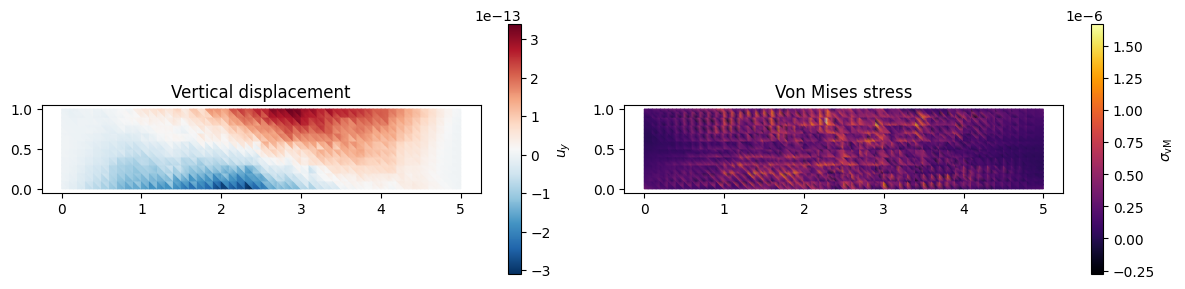

In [106]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Vertical displacement
c0 = tripcolor(u.sub(1), axes=axes[0], cmap="RdBu_r")
plt.colorbar(c0, ax=axes[0], label=r"$u_y$")
axes[0].set_aspect("equal")
axes[0].set_title("Vertical displacement")

# Von Mises stress
sig_vm = Function(FunctionSpace(mesh, "DG", 2), name="Von Mises stress")
sig_vm.interpolate(sqrt(
    sigma[0, 0]**2 - sigma[0, 0]*sigma[1, 1] + sigma[1, 1]**2
    + 3*sigma[0, 1]**2
))
c1 = tripcolor(sig_vm, axes=axes[1], cmap="inferno")
plt.colorbar(c1, ax=axes[1], label=r"$\sigma_\mathrm{vM}$")
axes[1].set_aspect("equal")
axes[1].set_title("Von Mises stress")

plt.tight_layout()
plt.show()